<a href="https://colab.research.google.com/github/kkeshavsharma/TITANIC/blob/main/titanic_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing Libraries**

In [ ]:
#kaggle titanic dataset is used in this project you can download it from kaggle website.
#download data from here = "https://www.kaggle.com/competitions/titanic/data"
import pandas as pd
from xgboost import XGBClassifier
import sqlite3

## **Loading Data**

In [ ]:
df = pd.read_csv("train.csv")
conn = sqlite3.connect("titanic.db")
df.to_sql(
    "titanic", conn, if_exists="replace", index= False
)
pd.read_sql("SELECT * FROM titanic", conn)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# **Data Cleaning**

ASCII conversion

In [ ]:
df.columns = df.columns.map(lambda x: x.encode ("ascii", "ignore").decode("ascii"))

manipulating data

In [ ]:
df["Embarked"]= df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"]= df["Embarked"].astype(str).str.strip().str.upper()
df["Embarked"]= df["Embarked"].map({"Q":0, "S":1, "C":2})
df["Sex"]= df["Sex"].map({"male":1 , "female":0})
df["Age"]= df["Age"].fillna(df["Age"].mean())
df["Fare"]= df["Fare"].fillna(df["Fare"].mode()[0])
#df["Survived"]= df["Survived"].fillna(df["Survived"].mode())
#will not select PassengerId in important features.
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,NaN,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,1
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,NaN,1
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,B42,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,NaN,1
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,C148,2


 **Manipulating ticket data**

In [ ]:
from pandas.core import groupby
df["Ticket"] = df["Ticket"].replace("LINE","LINE 0")
df["Prefix"] = df["Ticket"].str.extract('([A-Za-z]+)', expand = False)
dup_ticket = df.groupby("Ticket").size()
df["DupTicket"] = df["Ticket"].map(dup_ticket)
boy_or_female= (df.Name.str.contains("Master")) | ((df.Sex == 1) & (df.Age < 13))
Tick_surv = df[boy_or_female].groupby("Ticket").Survived.mean()
df["TicketSurv"] = df["Ticket"].map(Tick_surv)
df["TicketSurv"] = df["TicketSurv"].fillna(df["Survived"].mean())
df["Prefix"] = df["Prefix"].fillna("NUM")
#df["Prefix"] = df["Prefix"].factorize()[0]
df["Prefix"] = df["Prefix"].astype(str).str.strip().str.upper()
df["Prefix"] = df["Prefix"].map({"NUM": 0, "A":1, "PC":2, "STON":3, "PP":4,"C":6 ,"SC":7 ,"S":8, "CA":9, "SO":10 ,"W":11 ,"SOTON":12})
df["Prefix"] = df["Prefix"].fillna(0)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prefix,DupTicket,TicketSurv
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,NaN,1,1.0,1,0.383838
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,2,2.0,1,0.383838
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,1,3.0,1,0.383838
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,1,0.0,2,0.383838
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,NaN,1,0.0,1,0.383838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,NaN,1,0.0,1,0.383838
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,B42,1,0.0,1,0.383838
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,NaN,1,11.0,2,0.383838
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,C148,2,0.0,1,0.383838


**Manupulating Fare with PClass for cabin**

In [ ]:
df["Deck"] = df["Cabin"].fillna('Unknown').str.get(0)
df["Deck"] = df["Deck"].map({"A": 0, "B":1, "C":2, "D":4, "E":5, "F":6, "G":7 ,"T":00, "U":00})
df["Fare"] = df.groupby("Pclass")["Fare"].transform(lambda x: x.fillna(x.median()))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Prefix,DupTicket,TicketSurv,Deck
0,1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,NaN,1,1.0,1,0.383838,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C85,2,2.0,1,0.383838,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,1,3.0,1,0.383838,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,C123,1,0.0,2,0.383838,2
4,5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,NaN,1,0.0,1,0.383838,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.0000,NaN,1,0.0,1,0.383838,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.0000,B42,1,0.0,1,0.383838,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.4500,NaN,1,11.0,2,0.383838,0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.0000,C148,2,0.0,1,0.383838,2


### **CHEACKING for NULL**

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**to avoid data leakage**

In [ ]:
train_df = df[df["Survived"].notna()]
test_df = df[df["Survived"].isna()]

## **Train Test Split**

In [ ]:
trainingSet = df[["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked","Prefix","DupTicket","TicketSurv","Deck"]]
x = trainingSet.loc[train_df.index]
y = train_df["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 50)

# **APPLYING XGBOOST CLASSIFIER**

In [ ]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
scale_pos_weight = scale_pos_weight

In [ ]:
from numpy.random import logistic
xgb = XGBClassifier(
    max_depth=4,
    min_child_weight=4,
    learning_rate=0.03,
    n_estimators=700,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    max_delta_step=1,
    eval_metric="logloss",
    tree_method="hist",
    random_state=50
)
xgb.fit(x_train,y_train, eval_set=[(x_test,y_test)], verbose= False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=4, max_leaves=None, min_child_weight=4, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, ...)

**feature importance**

In [ ]:
xgb.feature_importances_

array([0.1014714 , 0.39580822, 0.03840274, 0.03261147, 0.03931354,
       0.03992724, 0.03701254, 0.05116364, 0.04069475, 0.15370765,
       0.06988682], dtype=float32)

## **MAKING PREDICTIONS**

In [ ]:
proba= xgb.predict_proba(x_test)

In [ ]:
y_pred = (proba[:,1] > 0.5).astype(int)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1])

In [ ]:
#Pclass,	Sex, 	Age, 	SibSp, 	Parch, 	Ticket, 	Fare 	Cabin 	Embarked 	Prefix 	DupTicket 	TicketSurv 	Deck
xgb.predict([[2,	1,	14.0,	0,	1,	7.2500,		1,	0.0,	1,	0.383838, 2]])

array([0])

In [ ]:
xgb.predict_proba([[3,	1,	22.0,	1,	0,	7.2500,		1,	0.0,	1,	0.383838, 0]])

array([[0.9668562 , 0.03314384]], dtype=float32)

## **ACCURACY**

In [ ]:
xgb.score(x_test,y_test)

0.8324022346368715

## **CONFUSION MATRIX AND CLASSIFICATION REPORT**

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[90 11]
 [19 59]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       101
           1       0.84      0.76      0.80        78

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



## **DATA VISUALIZATION**

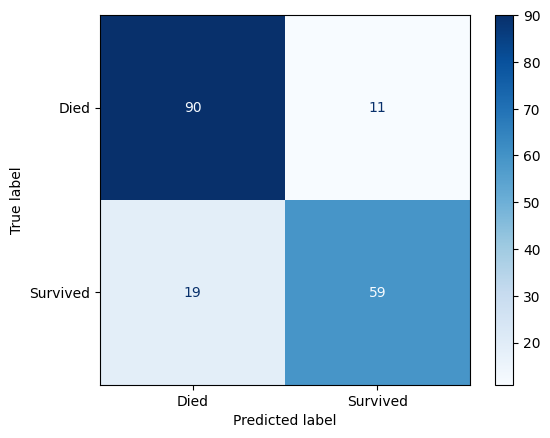

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = xgb.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Died", "Survived"]
)

disp.plot(cmap="Blues")
plt.show()
